## WholeSale Customer Segmentation

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [4]:
# load the dataset

df = pd.read_csv(r"C:\Data Analyst\Wholesale customers data.csv")

df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [5]:
df.shape

(440, 8)

## Exploratory Data Analysis

In [6]:
# check for null
df.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [7]:
#check dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [8]:
# check the dataset descriptive statistic
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [14]:
# feature selection
X = df[['Fresh', 'Milk', 'Grocery', 'Frozen','Detergents_Paper', 'Delicassen']]

X

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...
435,29703,12051,16027,13135,182,2204
436,39228,1431,764,4510,93,2346
437,14531,15488,30243,437,14841,1867
438,10290,1981,2232,1038,168,2125


<Axes: xlabel='Milk', ylabel='Count'>

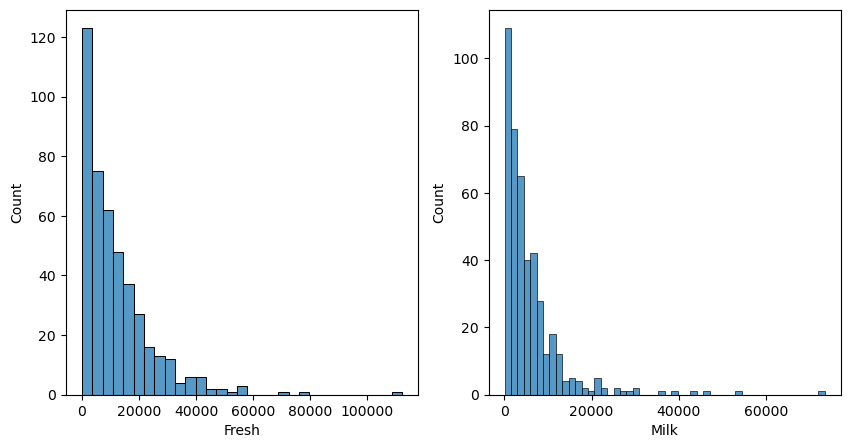

In [29]:
#plotting the histogram to check the skewness
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(df['Fresh'])

plt.subplot(1,2,2)
sns.histplot(df['Milk'])

In [30]:
# The columns are Right-skewed (positive skew), so we use logarithmic transformation.


In [31]:
# logarithmic transformation
X_log = np.log1p(X)

In [32]:
#standard scaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_log)

In [35]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

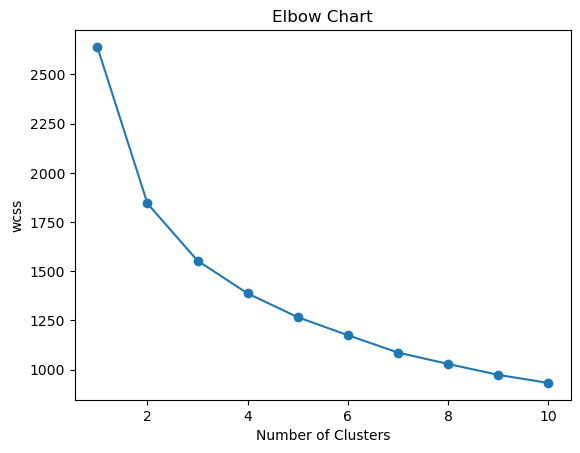

In [36]:
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Chart')
plt.xlabel('Number of Clusters')
plt.ylabel('wcss')
plt.show()

In [38]:
# train the final model

kmeans1 = KMeans(n_clusters=3, n_init=10, random_state=42)

#fit
kmeans1.fit(X_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [39]:
#predict

cluster = kmeans1.predict(X_scaled)

df['cluster'] = cluster

In [43]:
df.groupby(cluster)[['Fresh', 'Milk', 'Grocery', 'Frozen','Detergents_Paper', 'Delicassen']].mean()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2898.575000,7135.937500,12569.712500,606.550000,5554.387500,782.862500
1,17042.836735,10559.666667,13333.598639,4133.095238,4987.020408,2846.591837
2,11938.723005,2005.685446,2502.093897,3265.544601,424.478873,891.384977


In [50]:
df.groupby('cluster')[['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']].mean()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,
0,2898.575000,7135.937500,12569.712500,606.550000,5554.387500,782.862500
1,17042.836735,10559.666667,13333.598639,4133.095238,4987.020408,2846.591837
2,11938.723005,2005.685446,2502.093897,3265.544601,424.478873,891.384977


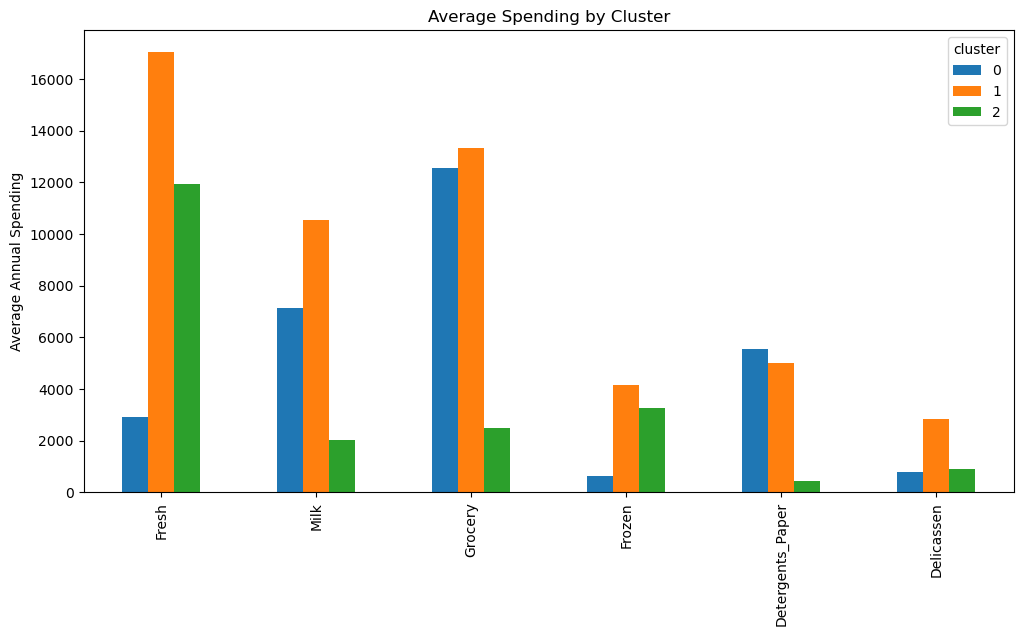

In [49]:
cluster_mean = df.groupby('cluster')[['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']].mean()

cluster_mean.T.plot(kind='bar', figsize=(12,6))
plt.title('Average Spending by Cluster')
plt.ylabel('Average Annual Spending')
plt.show()

In [53]:
# Evaluate the clustering

from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, cluster)

print(score)

0.25941565559741453
